# Wasserstein Ascend Descend
### (C. and N.) Garcia Trillos

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
from Robust_nn.WAD import WAD2scale
import matplotlib.pyplot as plt
from utils.utils import read_vision_dataset
from utils.convnet import ConvNet
from utils.convnet_silu import ConvNetSiLU
import os
import torch
import gc
import torch.nn as nn
from torch.optim.swa_utils import AveragedModel, SWALR


**Read the DataLoader**

In [3]:
# Create some networks

# n_nets = 5
n_nets = 5
net_lst = [ConvNet(add_dropout= False) for i in range(n_nets)]
avg_nets =[ConvNet(add_dropout= False) for i in range(n_nets*4)]

# adv_net = WAD2scale(net_list = net_lst, avg_nets = avg_nets, 
#                     dataset_name='MNIST',batch_size = 1024, 
#                     device = None , criterion= nn.CrossEntropyLoss(), 
#                     scale_factor=5, num_adverse=2,
#                     kappa = { 'param': 0.2, 'adv': 0.2   },
#                     max_batches= 5)


# adv_net = WAD2scale(net_list = net_lst, avg_nets = avg_nets, 
#                     dataset_name='MNIST',batch_size = 64, 
#                     device = None , criterion= nn.CrossEntropyLoss(), 
#                     scale_factor=3, num_adverse=2,
#                     penalty_coef = 3,
#                     kappa = { 'param': 0.25, 'adv': 0.15  },
#                     max_batches= 80)



                    
adv_net = WAD2scale(net_list = net_lst, avg_nets = avg_nets, 
                    dataset_name='MNIST',batch_size = 64, 
                    device = None , criterion= nn.CrossEntropyLoss(), 
                    scale_factor=5, num_adverse=3,
                    penalty_coef = 10,
                    kappa = { 'param': 0.25, 'adv': 0.25  },
                    max_batches= 937)
# adv_net = WAD2scale(net_list = net_lst, avg_nets = avg_nets, 
#                     dataset_name='MNIST',batch_size = 64, 
#                     device = None , criterion= nn.CrossEntropyLoss(), 
#                     scale_factor=3, num_adverse=2,
#                     penalty_coef = 10,
#                     kappa = { 'param': 0.25, 'adv': 0.25  },
#                     max_batches= 937)

In [4]:
import os
os.listdir('.')

['.git',
 '.vscode',
 'checkpoint',
 'Robust_nn',
 'Robust_reg_code.zip',
 'Test1_kappaC',
 'Tests_o1o2.ipynb',
 'Tests_WAD.ipynb',
 'Tests_Wad_script.py',
 'todo.md',
 'utils',
 '_avg_adv_folder',
 '_avg_adv_folder C']

In [5]:
adv_net.set_optimizer()
adv_net.train(epochs=5)


Epoch: 0
 
0|1|2|3|4|5|6|7|8|9|10|11|12|13|14|15|16|17|18|19|20|21|22|23|24|25|26|27|28|29| 
30|31|32|33|34|35|36|37|38|39|40|41|42|43|44|45|46|47|48|49|50|51|52|53|54|55|56|57|58|59| 
60|61|62|63|64|65|66|67|68|69|70|71|72|73|74|75|76|77|78|79|80|81|82|83|84|85|86|87|88|89| 
90|91|92|93|94|95|96|97|98|99|100|101|102|103|104|105|106|107|108|109|110|111|112|113|114|115|116|117|118|119| 
120|121|122|123|124|125|126|127|128|129|130|131|132|133|134|135|136|137|138|139|140|141|142|143|144|145|146|147|148|149| 
150|151|152|153|154|155|156|157|158|159|160|161|162|163|164|165|166|167|168|169|170|171|172|173|174|175|176|177|178|179| 
180|181|182|183|184|185|186|187|188|189|190|191|192|193|194|195|196|197|198|199|200|201|202|203|204|205|206|207|208|209| 
210|211|212|213|214|215|216|217|218|219|220|221|222|223|224|225|226|227|228|229|230|231|232|233|234|235|236|237|238|239| 
240|241|242|243|244|245|246|247|248|249|250|251|252|253|254|255|256|257|258|259|260|261|262|263|264|265|266|267|268|269| 


KeyboardInterrupt: 

In [ ]:
adv_net.save_model('Test1_kappaA')

Saving...
done.


In [ ]:
# adv_net.set_optimizer()
# adv_net.import_model('Test1_kappaC')

Loading...
done.


In [ ]:
'''
Testing the model 

Peform the following tests:
1. Test for accuracy of the average  model
2. Train directly the model with the whole set of adversaries. Calculate...
3. Create directly the adversarial. 
'''

'\nTesting the model \n\nPeform the following tests:\n1. Test for accuracy of the average  model\n2. Train directly the model with the whole set of adversaries. Calculate...\n3. Create directly the adversarial. \n'

In [ ]:
adv_net.test_pgd(20)

epoch = 20, adv_acc = 65.38, clean_acc = 95.34
Saving the best model to ./checkpoint
Saving...
done.


(0.20632506180317348, 65.38, 95.34)

In [ ]:
# adv_net.test_base()

In [ ]:
val_at_nash = adv_net.test_base()

 
0|1|2|3|4|5|6|7|8|9|10|11|12|13|14|15|16|17|18|19|20|21|22|23|24|25|26|27|28|29| 
30|31|32|33|34|35|36|37|38|39|40|41|42|43|44|45|46|47|48|49|50|51|52|53|54|55|56|57|58|59| 
60|61|62|63|64|65|66|67|68|69|70|71|72|73|74|75|76|77|78|79|80|81|82|83|84|85|86|87|88|89| 
90|91|92|93|94|95|96|97|98|99|100|101|102|103|104|105|106|107|108|109|110|111|112|113|114|115|116|117|118|119| 
120|121|122|123|124|125|126|127|128|129|130|131|132|133|134|135|136|137|138|139|140|141|142|143|144|145|146|147|148|149| 
150|151|152|153|154|155|156|157|158|159|160|161|162|163|164|165|166|167|168|169|170|171|172|173|174|175|176|177|178|179| 
180|181|182|183|184|185|186|187|188|189|190|191|192|193|194|195|196|197|198|199|200|201|202|203|204|205|206|207|208|209| 
210|211|212|213|214|215|216|217|218|219|220|221|222|223|224|225|226|227|228|229|230|231|232|233|234|235|236|237|238|239| 
240|241|242|243|244|245|246|247|248|249|250|251|252|253|254|255|256|257|258|259|260|261|262|263|264|265|266|267|268|269| 
270|271|27

In [ ]:
val_better_adv = adv_net.test_improve_adversaries(5)

 
0|1|2|3|4|5|6|7|8|9|10|11|12|13|14|15|16|17|18|19|20|21|22|23|24|25|26|27|28|29| 
30|31|32|33|34|35|36|37|38|39|40|41|42|43|44|45|46|47|48|49|50|51|52|53|54|55|56|57|58|59| 
60|61|62|63|64|65|66|67|68|69|70|71|72|73|74|75|76|77|78|79|80|81|82|83|84|85|86|87|88|89| 
90|91|92|93|94|95|96|97|98|99|100|101|102|103|104|105|106|107|108|109|110|111|112|113|114|115|116|117|118|119| 
120|121|122|123|124|125|126|127|128|129|130|131|132|133|134|135|136|137|138|139|140|141|142|143|144|145|146|147|148|149| 
150|151|152|153|154|155|156|157|158|159|160|161|162|163|164|165|166|167|168|169|170|171|172|173|174|175|176|177|178|179| 
180|181|182|183|184|185|186|187|188|189|190|191|192|193|194|195|196|197|198|199|200|201|202|203|204|205|206|207|208|209| 
210|211|212|213|214|215|216|217|218|219|220|221|222|223|224|225|226|227|228|229|230|231|232|233|234|235|236|237|238|239| 
240|241|242|243|244|245|246|247|248|249|250|251|252|253|254|255|256|257|258|259|260|261|262|263|264|265|266|267|268|269| 
270|271|27

In [ ]:
val_better_model = adv_net.test_improve_model(5)

 
0|1|2|3|4|5|6|7|8|9|10|11|12|13|14|15|16|17|18|19|20|21|22|23|24|25|26|27|28|29| 
30|31|32|33|34|35|36|37|38|39|40|41|42|43|44|45|46|47|48|49|50|51|52|53|54|55|56|57|58|59| 
60|61|62|63|64|65|66|67|68|69|70|71|72|73|74|75|76|77|78|79|80|81|82|83|84|85|86|87|88|89| 
90|91|92|93|94|95|96|97|98|99|100|101|102|103|104|105|106|107|108|109|110|111|112|113|114|115|116|117|118|119| 
120|121|122|123|124|125|126|127|128|129|130|131|132|133|134|135|136|137|138|139|140|141|142|143|144|145|146|147|148|149| 
150|151|152|153|154|155|156|157|158|159|160|161|162|163|164|165|166|167|168|169|170|171|172|173|174|175|176|177|178|179| 
180|181|182|183|184|185|186|187|188|189|190|191|192|193|194|195|196|197|198|199|200|201|202|203|204|205|206|207|208|209| 
210|211|212|213|214|215|216|217|218|219|220|221|222|223|224|225|226|227|228|229|230|231|232|233|234|235|236|237|238|239| 
240|241|242|243|244|245|246|247|248|249|250|251|252|253|254|255|256|257|258|259|260|261|262|263|264|265|266|267|268|269| 
270|271|27

In [ ]:
#Check the order

print(val_better_model<=val_at_nash<=val_better_adv)

True


In [ ]:
# Percentage of change

print( 'Relative Interval:', 1 - val_better_model/val_at_nash, val_better_adv/val_at_nash -1    )

Relative Interval: -0.038203152832613 -0.0022723271278257684


In [ ]:
# type(val_better_model)

float

In [ ]:

# img = []


# miter = iter(adv_net.trainloader)
# for i in range(2):
#     aux = next(miter)
#     img.append(aux[0].unsqueeze(0))
#     tgt = aux[1]

# img = torch.cat(img, dim=0)
# # tgt = torch.cat(tgt, dim=0)

# print(img.shape, tgt.shape)

torch.Size([2, 64, 1, 28, 28]) torch.Size([64])


tensor(4)


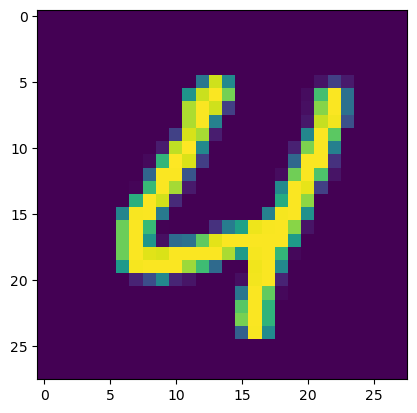

In [ ]:
# print(aux[1][0])
# plt.imshow( np.squeeze(aux[0])[0,:,:])


In [ ]:
# aux[0][0].shape

torch.Size([1, 28, 28])

In [ ]:
# adv_net._compute_loss_avg (2, adv_net.net_list, adv_net.net_weights, img, img, tgt , input_grad=False)

tensor(0.8453, grad_fn=<SumBackward0>)

In [ ]:
# aux[0].shape

torch.Size([64, 1, 28, 28])

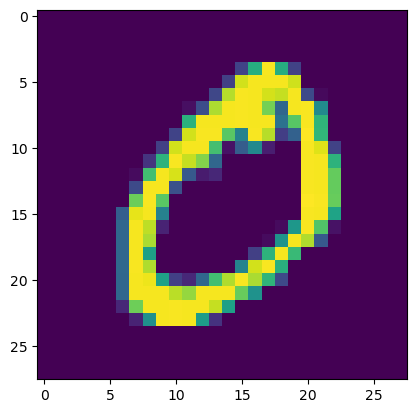

In [ ]:
# plt.imshow( img.squeeze()[0,1,...])


In [ ]:
# for batch_idx, (inputs, targets) in enumerate(adv_net.trainloader):
#     if inputs.shape[0]!=64:
#         print (batch_idx, ' : ', inputs.shape[0])

937  :  32


In [ ]:
# imgs = os.listdir(os.path.join('.','_avg_adv_folder','weights'))
# for im in imgs:
#     print(im[6:], end=', ')

0.pt, 1.pt, 10.pt, 100.pt, 101.pt, 102.pt, 103.pt, 104.pt, 105.pt, 106.pt, 107.pt, 108.pt, 109.pt, 11.pt, 110.pt, 111.pt, 112.pt, 113.pt, 114.pt, 115.pt, 116.pt, 117.pt, 118.pt, 119.pt, 12.pt, 120.pt, 121.pt, 122.pt, 123.pt, 124.pt, 125.pt, 126.pt, 127.pt, 128.pt, 129.pt, 13.pt, 130.pt, 131.pt, 132.pt, 133.pt, 134.pt, 135.pt, 136.pt, 137.pt, 138.pt, 139.pt, 14.pt, 140.pt, 141.pt, 142.pt, 143.pt, 144.pt, 145.pt, 146.pt, 147.pt, 148.pt, 149.pt, 15.pt, 150.pt, 151.pt, 152.pt, 153.pt, 154.pt, 155.pt, 156.pt, 157.pt, 158.pt, 159.pt, 16.pt, 160.pt, 161.pt, 162.pt, 163.pt, 164.pt, 165.pt, 166.pt, 167.pt, 168.pt, 169.pt, 17.pt, 170.pt, 171.pt, 172.pt, 173.pt, 174.pt, 175.pt, 176.pt, 177.pt, 178.pt, 179.pt, 18.pt, 180.pt, 181.pt, 182.pt, 183.pt, 184.pt, 185.pt, 186.pt, 187.pt, 188.pt, 189.pt, 19.pt, 190.pt, 191.pt, 192.pt, 193.pt, 194.pt, 195.pt, 196.pt, 197.pt, 198.pt, 199.pt, 2.pt, 20.pt, 200.pt, 201.pt, 202.pt, 203.pt, 204.pt, 205.pt, 206.pt, 207.pt, 208.pt, 209.pt, 21.pt, 210.pt, 211.pt, 21